In [1]:
import pandas as pd

# Path to the dataset
DATA_PATH = "/kaggle/input/datasets/fhabibimoghaddam/customer-credit-card-data/Customer_Data.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display dataset shape and first 5 rows
print(df.shape)
print(df.head())

(8950, 18)
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONE_OFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40               0.00   
1  C10002  3202.467416           0.909091       0.00               0.00   
2  C10003  2495.148862           1.000000     773.17             773.17   
3  C10004  1666.670542           0.636364    1499.00            1499.00   
4  C10005   817.714335           1.000000      16.00              16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONE_OFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                     0.000000                          0.083333   
1                

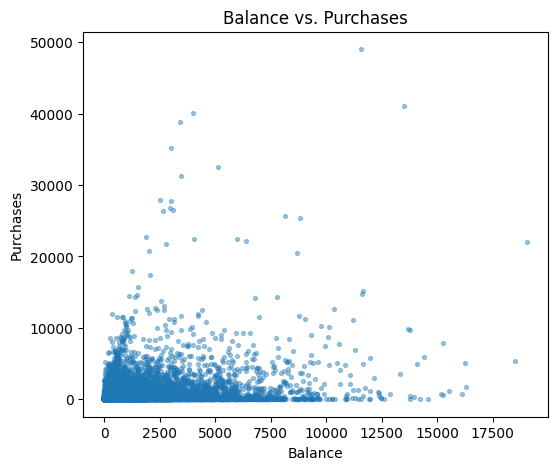

In [2]:
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(6, 5))

plt.scatter(
    df["BALANCE"],
    df["PURCHASES"],
    s=8,
    alpha=0.4
)

# Add labels
plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("Balance vs. Purchases")

# Display the plot
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

# Select features
feature_cols = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

# Fill missing values with the median
df[feature_cols] = df[feature_cols].fillna(
    df[feature_cols].median()
)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols].values)

print(X_scaled[:5])


[[-0.73198937 -0.42489974 -0.46678555 -0.9603784  -0.52897879]
 [ 0.78696085 -0.46955188  2.60560451  0.68867844  0.81864213]
 [ 0.44713513 -0.10766823 -0.46678555  0.82609984 -0.38380474]
 [ 0.04909914  0.23205785 -0.36865325  0.82609984 -0.59868826]
 [-0.3587753  -0.46206305 -0.46678555 -0.90540984 -0.3643678 ]]


In [4]:
from sklearn.cluster import KMeans

# Create the K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [5]:
# Assign each customer to a cluster
df["Cluster"] = kmeans.predict(X_scaled)

# Display the number of customers in each cluster
print(df["Cluster"].value_counts())

Cluster
1    5991
0    2092
2     788
3      79
Name: count, dtype: int64


In [6]:
from sklearn.metrics import silhouette_score

# Calculate and display the Silhouette Score
score = silhouette_score(X_scaled, df["Cluster"])
print(f"Silhouette Score: {score:.3f}")

# Calculate the average feature values for each cluster
cluster_summary = df.groupby("Cluster")[feature_cols].mean()

print(cluster_summary)


Silhouette Score: 0.404
             BALANCE     PURCHASES  CASH_ADVANCE  CREDIT_LIMIT      PAYMENTS
Cluster                                                                     
0        2038.788401   1965.051477    639.905956   7983.977925   2503.883960
1         788.150522    491.801187    483.805473   2526.763774    868.739008
2        5918.962965    853.247297   5607.605148   9353.939778   4609.398988
3        4442.427570  15810.832785   1328.376614  12817.721519  18185.954830
